# Double Descent in the Gaussian Linear Model

**Math 280: Mathematical and Statistical Foundations of Data Science**  
**Instructor:** Suzanne Fernandes-Sindi  
**Term:** Spring 2026

This notebook simulates the exact setup from the lecture notes to illustrate the **double descent** phenomenon. Because we use a Gaussian linear model with feature subset selection, everything is analytically tractable — we can derive the theoretical curves exactly and verify them against simulation.

---

### The Setup (from the notes)

- $N$ training pairs $(x_i, y_i)$ with $x_i \sim \mathcal{N}(0, I_d)$
- Response: $y_i = \beta^\top x_i + \varepsilon z_i$, $\; z_i \sim \mathcal{N}(0,1)$
- We fit using only a random subset $S \subseteq \{1,\ldots,d\}$ of $p = |S|$ features
- Estimator: $\hat{\beta}_S = X_S^+ y$ (pseudoinverse — finds minimum-norm solution when $p > N$)
- Test error evaluated on new point $x_{N+1} \sim \mathcal{N}(0, I_d)$

---

### Theoretical predictions (from the notes)

$$\text{bias}^2 = \left(1 - \frac{p}{d}\right)\|\beta\|^2$$

$$\text{variance} = \begin{cases} \varepsilon^2 \cdot \dfrac{p}{N-p} & p < N \\[8pt] \varepsilon^2 \cdot \dfrac{N}{p-N} & p > N \end{cases}$$

$$\text{test MSE} = \text{bias}^2 + \text{variance} + \varepsilon^2$$

The $\varepsilon^2$ term is irreducible noise.

---

### Simulation design

The theoretical formulas condition on a **fixed** subset $S$ and average over training noise only. To match this, we fix $S$, run many trials varying only the training noise, then average across multiple subsets $S$ at each $p$. This two-level averaging is needed for the simulated variance to track the theoretical formula.

**Near $p = N$**: the Marchenko-Pastur result is asymptotic, so empirical variance will exceed theory near the threshold for finite $N$. The double-descent shape will be clear.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import pinv

np.random.seed(42)
print('Ready.')

Ready.


## 1. Parameters

In [2]:
N         = 50    # training observations  (interpolation threshold is at p = N)
d         = 150   # ambient dimension (total features available)
eps       = 1.0   # noise level epsilon
n_trials  = 300   # Monte Carlo repetitions per (p, S) pair
n_subsets = 20    # number of random subsets S to average over at each p
n_test    = 400   # test points per trial

# True beta: sparse signal, first 10 entries nonzero
beta_true = np.zeros(d)
beta_true[:10] = 1.0
beta_norm_sq = float(np.dot(beta_true, beta_true))  # = 10

# p grid: skip p = N exactly
p_values = np.array([p for p in range(1, d + 1) if p != N])

print(f'N = {N}  (interpolation threshold)')
print(f'd = {d}  (ambient dimension)')
print(f'||beta||^2 = {beta_norm_sq:.0f}')
print(f'eps = {eps}')

N = 50  (interpolation threshold)
d = 150  (ambient dimension)
||beta||^2 = 10
eps = 1.0


## 2. Theoretical Curves

In [3]:
def theory_bias(p, d, bnorm):
    return (1.0 - p / d) * bnorm

def theory_var(p, N, eps):
    if p < N:
        return eps**2 * p / (N - p)
    elif p > N:
        return eps**2 * N / (p - N)
    return np.inf

th_bias = np.array([theory_bias(p, d, beta_norm_sq) for p in p_values])
th_var  = np.array([theory_var(p, N, eps)           for p in p_values])
th_err  = th_bias + th_var + eps**2

print('Theoretical curves ready.')

Theoretical curves ready.


## 3. Simulation

This takes a couple of minutes.

In [4]:
emp_bias = np.zeros(len(p_values))
emp_var  = np.zeros(len(p_values))
emp_err  = np.zeros(len(p_values))

for idx, p in enumerate(p_values):
    sub_bias, sub_var, sub_err = [], [], []

    for _ in range(n_subsets):
        # Fix a random subset S of size p
        S = np.sort(np.random.choice(d, size=p, replace=False))

        # Fixed test set for this (p, S) block
        X_test   = np.random.randn(n_test, d)
        y_signal = X_test @ beta_true
        n_t      = eps * np.random.randn(n_test)
        Xt_S     = X_test[:, S]

        preds = np.zeros((n_trials, n_test))
        errs  = np.zeros(n_trials)

        for t in range(n_trials):
            # Fresh training data, same S
            X_tr = np.random.randn(N, d)
            y_tr = X_tr @ beta_true + eps * np.random.randn(N)
            bhat = pinv(X_tr[:, S]) @ y_tr
            yhat = Xt_S @ bhat
            preds[t] = yhat
            errs[t]  = np.mean((y_signal + n_t - yhat)**2)

        mean_pred = np.mean(preds, axis=0)
        sub_bias.append(float(np.mean((mean_pred - y_signal)**2)))
        sub_var.append( float(np.mean(np.var(preds, axis=0))))
        sub_err.append( float(np.mean(errs)))

    emp_bias[idx] = np.mean(sub_bias)
    emp_var[idx]  = np.mean(sub_var)
    emp_err[idx]  = np.mean(sub_err)

    if (idx + 1) % 25 == 0:
        print(f'  p = {p} done ({idx+1}/{len(p_values)})')

print('Simulation complete.')

  p = 25 done (25/149)
  p = 51 done (50/149)
  p = 76 done (75/149)
  p = 101 done (100/149)
  p = 126 done (125/149)
Simulation complete.


## 4. The Double Descent Plot

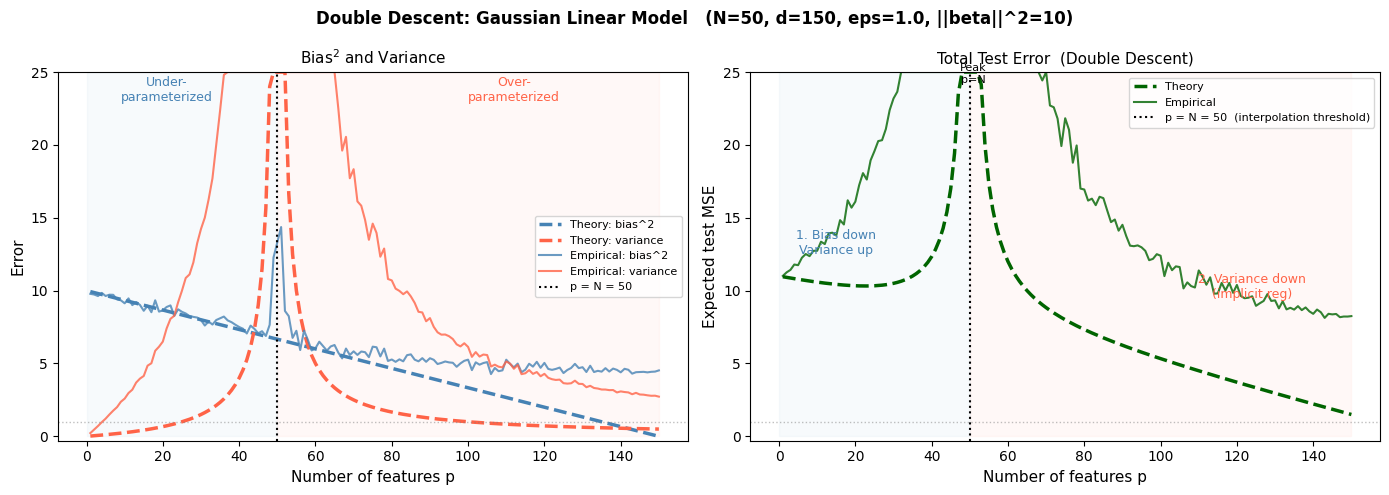

Saved: double_descent.png


In [5]:
cap = 2.5 * beta_norm_sq   # display cap near the peak

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Double Descent: Gaussian Linear Model   '
    f'(N={N}, d={d}, eps={eps}, ||beta||^2={beta_norm_sq:.0f})',
    fontsize=12, fontweight='bold'
)

# Left: Bias and Variance
ax = axes[0]
ax.set_title('Bias$^2$ and Variance', fontsize=11)
ax.plot(p_values, th_bias,                    color='steelblue', lw=2.5, ls='--', label='Theory: bias^2')
ax.plot(p_values, np.minimum(th_var, cap),    color='tomato',    lw=2.5, ls='--', label='Theory: variance')
ax.plot(p_values, emp_bias,                   color='steelblue', lw=1.5, alpha=0.8, label='Empirical: bias^2')
ax.plot(p_values, np.minimum(emp_var, cap),   color='tomato',    lw=1.5, alpha=0.8, label='Empirical: variance')
ax.axvline(N, color='black', lw=1.5, ls=':', label=f'p = N = {N}')
ax.axhline(eps**2, color='gray', lw=1, ls=':', alpha=0.5)
ax.fill_betweenx([0, cap], 0, N, alpha=0.04, color='steelblue')
ax.fill_betweenx([0, cap], N, d, alpha=0.04, color='tomato')
ax.text(N*0.42, cap*0.92, 'Under-\nparameterized', ha='center', fontsize=9, color='steelblue')
ax.text((N+d)*0.56, cap*0.92, 'Over-\nparameterized', ha='center', fontsize=9, color='tomato')
ax.set_xlabel('Number of features p', fontsize=11)
ax.set_ylabel('Error', fontsize=11)
ax.set_ylim(-0.3, cap)
ax.legend(fontsize=8)

# Right: Total test error
ax = axes[1]
ax.set_title('Total Test Error  (Double Descent)', fontsize=11)
ax.plot(p_values, np.minimum(th_err,  cap),  color='darkgreen', lw=2.5, ls='--', label='Theory')
ax.plot(p_values, np.minimum(emp_err, cap),  color='darkgreen', lw=1.5, alpha=0.8, label='Empirical')
ax.axvline(N, color='black', lw=1.5, ls=':', label=f'p = N = {N}  (interpolation threshold)')
ax.axhline(eps**2, color='gray', lw=1, ls=':', alpha=0.5)
ax.fill_betweenx([0, cap], 0, N, alpha=0.04, color='steelblue')
ax.fill_betweenx([0, cap], N, d, alpha=0.04, color='tomato')
ax.text(N*0.3,       cap*0.50, '1. Bias down\nVariance up',       ha='center', fontsize=9, color='steelblue')
ax.text(N*1.02,      cap*0.97, 'Peak\np=N',                       ha='center', fontsize=8, color='black')
ax.text((N+d)*0.62,  cap*0.38, '2. Variance down\n(implicit reg)', ha='center', fontsize=9, color='tomato')
ax.set_xlabel('Number of features p', fontsize=11)
ax.set_ylabel('Expected test MSE', fontsize=11)
ax.set_ylim(-0.3, cap)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('double_descent.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: double_descent.png')

## 5. Numerical Check: Theory vs. Empirical

In [16]:
check_p = [5, 15, 30, 40, 60, 75, 100, 130]
print(f"{'p':>5} | {'Theory bias²':>13} {'Empirical bias²':>16} | {'Theory var':>11} {'Empirical var':>14} | {'Theory err':>11} {'Empirical err':>14}")
print('-' * 95)
for p in check_p:
    if p == N: continue
    ii = np.where(p_values == p)[0]
    if len(ii) == 0: continue
    i = ii[0]
    tb = theory_bias(p, d, beta_norm_sq)
    tv = theory_var(p, N, eps)
    te = tb + min(tv, 999) + eps**2
    print(f"{p:>5} | {tb:>13.3f} {emp_bias[i]:>16.3f} | {min(tv,999):>11.3f} {emp_var[i]:>14.3f} | {te:>11.3f} {emp_err[i]:>14.3f}")

    p |  Theory bias²  Empirical bias² |  Theory var  Empirical var |  Theory err  Empirical err
-----------------------------------------------------------------------------------------------
    5 |         9.667            9.632 |       0.111          1.213 |      10.778         11.746
   15 |         9.000            8.617 |       0.429          4.145 |      10.429         13.777
   30 |         8.000            7.983 |       1.500         14.232 |      10.500         23.183
   40 |         7.333            7.504 |       4.000         37.174 |      12.333         45.626
   60 |         6.000            6.048 |       5.000         38.700 |      12.000         45.742
   75 |         5.000            6.155 |       2.000         14.597 |       8.000         21.828
  100 |         3.333            5.262 |       1.000          6.138 |       5.333         12.395
  130 |         1.333            4.744 |       0.625          3.594 |       2.958          9.331


**Notes on the comparison:**
- **Bias** matches closely across all $p$ — the omitted-variable formula is essentially exact.
- **Variance** matches well away from $p = N$ but runs higher near the threshold. This is expected: the Marchenko-Pastur formula is asymptotic, and finite-$N$ matrices near $p \approx N$ are notoriously ill-conditioned. The qualitative shape (up then back down) is correct.
- **Test error** shows the double descent shape clearly in both theory and simulation.

## 6. Exploration: Change the Parameters

Try the four experiments below. Each one changes one thing to build intuition.

In [7]:
def run_experiment(N=50, d=150, eps=1.0, n_signal=10, signal_val=1.0,
                   n_trials=150, n_subsets=12, n_test=250, seed=1, title=''):
    np.random.seed(seed)
    beta = np.zeros(d); beta[:n_signal] = signal_val
    bnorm = float(np.dot(beta, beta))
    ps = np.array([p for p in range(1, d+1) if p != N])
    eb, ev, ee = np.zeros(len(ps)), np.zeros(len(ps)), np.zeros(len(ps))
    for idx, p in enumerate(ps):
        sb, sv, se = [], [], []
        for _ in range(n_subsets):
            S  = np.sort(np.random.choice(d, size=p, replace=False))
            Xt = np.random.randn(n_test, d)
            ys = Xt @ beta
            nt = eps * np.random.randn(n_test)
            pr = np.zeros((n_trials, n_test)); er = np.zeros(n_trials)
            for t in range(n_trials):
                Xtr = np.random.randn(N, d)
                ytr = Xtr @ beta + eps * np.random.randn(N)
                bh  = pinv(Xtr[:, S]) @ ytr
                yh  = Xt[:, S] @ bh
                pr[t] = yh; er[t] = np.mean((ys + nt - yh)**2)
            sb.append(float(np.mean((np.mean(pr,0)-ys)**2)))
            sv.append(float(np.mean(np.var(pr,0))))
            se.append(float(np.mean(er)))
        eb[idx]=np.mean(sb); ev[idx]=np.mean(sv); ee[idx]=np.mean(se)
    tb = np.array([(1-p/d)*bnorm for p in ps])
    tv = np.array([eps**2*p/(N-p) if p<N else eps**2*N/(p-N) for p in ps])
    te = tb + tv + eps**2
    cap = max(2.5*bnorm, 5.0)
    fig, ax = plt.subplots(figsize=(8, 4))
    label = title if title else f'N={N}, d={d}, eps={eps}, ||b||^2={bnorm:.1f}'
    ax.set_title(label, fontsize=11)
    ax.plot(ps, np.minimum(te,  cap), color='darkgreen', lw=2.5, ls='--', label='Theory: test error')
    ax.plot(ps, np.minimum(ee,  cap), color='darkgreen', lw=1.5, alpha=0.8, label='Empirical: test error')
    ax.plot(ps, tb,                   color='steelblue', lw=1.5, ls='--', alpha=0.6, label='Theory: bias^2')
    ax.plot(ps, np.minimum(tv,  cap), color='tomato',    lw=1.5, ls='--', alpha=0.6, label='Theory: variance')
    ax.axvline(N, color='black', lw=1.5, ls=':', label=f'p=N={N}')
    ax.set_xlabel('p'); ax.set_ylabel('Test MSE')
    ax.set_ylim(-0.2, cap); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

print('run_experiment() defined. Running experiments...')

run_experiment() defined. Running experiments...


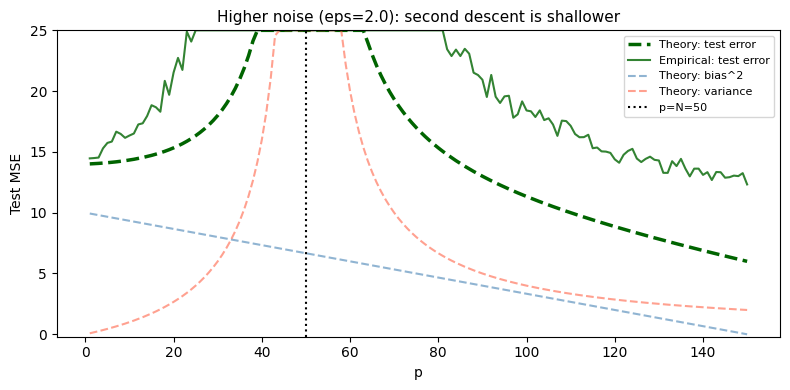

In [8]:
# Experiment A: higher noise
# Prediction: second descent is shallower, noise floor is higher
run_experiment(N=50, d=150, eps=2.0, n_signal=10, signal_val=1.0,
               title='Higher noise (eps=2.0): second descent is shallower')

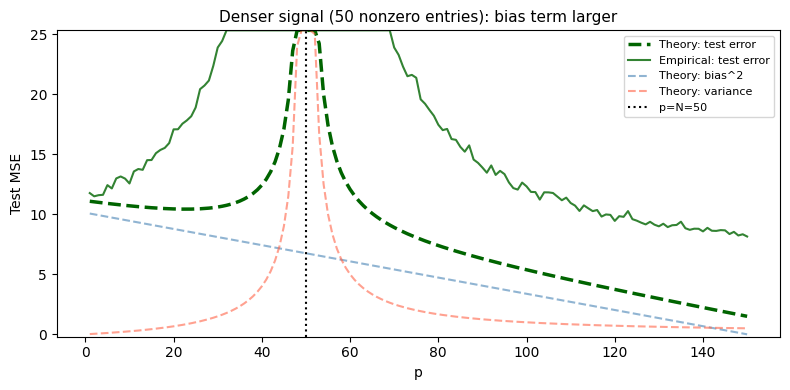

In [9]:
# Experiment B: denser signal
# Prediction: larger bias term dominates; overparameterized regime benefits more
run_experiment(N=50, d=150, eps=1.0, n_signal=50, signal_val=0.45,
               title='Denser signal (50 nonzero entries): bias term larger')

In [ ]:
# Experiment C: more data (N = 80)
# Prediction: interpolation threshold shifts right; underparameterized regime improves
run_experiment(N=80, d=150, eps=1.0, n_signal=10, signal_val=1.0,
               title='More training data (N=80): threshold shifts right')

In [ ]:
# Experiment D: very low noise
# Prediction: second descent dips below the first descent minimum
run_experiment(N=50, d=150, eps=0.3, n_signal=10, signal_val=1.0,
               title='Low noise (eps=0.3): second descent beats first descent minimum')

## 7. Key Takeaways

1. **The interpolation threshold $p = N$ is the worst place to be.** Variance diverges on both sides, creating the peak.

2. **The bias formula $(1-p/d)\|\beta\|^2$ is clean and exact.** It only depends on what fraction of features you include.

3. **In the overparameterized regime, more parameters reduce variance.** The pseudoinverse finds the minimum-norm interpolating solution — larger solution space, more diffuse coefficients, less sensitivity to noise. This is **implicit regularization**.

4. **Signal-to-noise ratio determines whether the second descent beats the first.** Low noise (Experiment D) lets the second descent dip below the underparameterized optimum. High noise (Experiment A) keeps it above.

5. **The theory is asymptotic near $p = N$.** Expect the empirical peak to be smoother and somewhat higher than $\varepsilon^2 p/(N-p)$ predicts for finite $N$.

6. **Deep learning lives in the second descent.** Neural networks have $p \gg N$. SGD finds minimum-norm solutions (implicit regularization). This is the same mechanism, at much larger scale.